# BrushCue Example: Film Noir

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/film_noir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/film-noir

In [ ]:
!pip install brushcue

new pipeline: painter_Tessellated_fill_solid_no_brush_sample_true_rgba16float
new pipeline: color_transformer_shader_rgba16float_compute_16683618810569050274_inarr_false
new pipeline: spacial_displacement_shader_rgba16float_compute_15511498967903287358_inarr_false
new pipeline: color_transformer_shader_rgba16float_compute_16484084215151346772_inarr_false
new pipeline: convolution_rgba16float_compute_true_inarr_false
new pipeline: color_transformer_shader_rgba16float_compute_7675507057223931672_inarr_false
new pipeline: point_effect_shader_rgba16float_compute_8660679059503942732_inarr_false
new pipeline: color_transformer_shader_rgba16float_compute_16861657794771480865_inarr_false


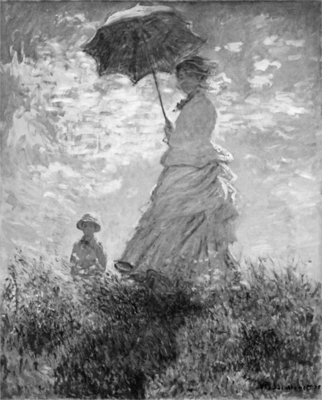

In [1]:
import io
from PIL import Image

import brushcue as bc

variable_0 = bc.Composition.monet_women_with_parasol()
graph = (
    variable_0.film_grain(1.51, 150, 0.5, 51, 0.3, 300, 0.2)
    .gaussian_blur(2)
    .grayscale()
    .l_curve(bc.Curve.pivoted_sigmoid(0.5, 3.2))
    .vignette(
        bc.Vector2f.from_components(
            (variable_0.bounds().width() / 2), (variable_0.bounds().height() / 2)
        ),
        (variable_0.bounds().width() / 2),
        (variable_0.bounds().height() / 2),
        454,
        0.32999998,
    )
    .crop(variable_0.bounds())
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
